<a href="https://colab.research.google.com/github/TBGhorbanpour/Social-Awareness/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Install Libraries**

In [ ]:
!pip install https://github.com/roshan-research/hazm/archive/master.zip --upgrade

In [ ]:
!pip install --upgrade gensim networkx matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 33.2 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.7.1
    Uninstalling matplotlib-3.7.1:
      Successfully uninstalled matplotlib-3.7.1


In [ ]:
!pip install transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 14.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 20.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 34.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.9 MB/s eta 0:00:00


In [ ]:
!pip install gensim

In [ ]:
!pip show gensim

Name: gensim
Version: 4.3.2
Summary: Python framework for fast Vector Space Modelling
Home-page: https://radimrehurek.com/gensim/
Author: Radim Rehurek
Author-email: me@radimrehurek.com
License: LGPL-2.1-only
Location: /usr/local/lib/python3.10/dist-packages
Requires: numpy, scipy, smart-open
Required-by: 


In [ ]:
!pip install scikit-learn

In [ ]:
!pip install arabic_reshaper python-bidi

In [ ]:
!pip install pandas TextBlob

In [ ]:
!pip install pandas
!pip install networkx

In [ ]:
!pip install numpy
!pip install --upgrade gensim


#**load Libraries**

In [ ]:
import pandas as pd
from gensim.models import Word2Vec
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import arabic_reshaper
from bidi.algorithm import get_display
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from transformers import AutoConfig, AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import Lasso
import gensim
from gensim import corpora, models
from gensim.models import LdaModel
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from scipy.cluster.hierarchy import dendrogram, linkage
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import pipeline
import torch
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from textblob import TextBlob

#**load dataset**

In [ ]:
from google.colab import drive

# This will prompt you to authenticate and authorize access to your Google Drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Thesis/Data/Tweeds/Elham/ready_to_graph_FSelectDB.csv')


Mounted at /content/drive


In [ ]:
df.head(10)

In [ ]:
df.shape

(14205, 16)

#**Arabic Reshaper**

In [ ]:
from bidi.algorithm import get_display
import arabic_reshaper
def make_farsi_text(x):
  reshaped_text = arabic_reshaper.reshape(x)
  farsi_text = get_display(reshaped_text)
  return farsi_text

#**Graphs**

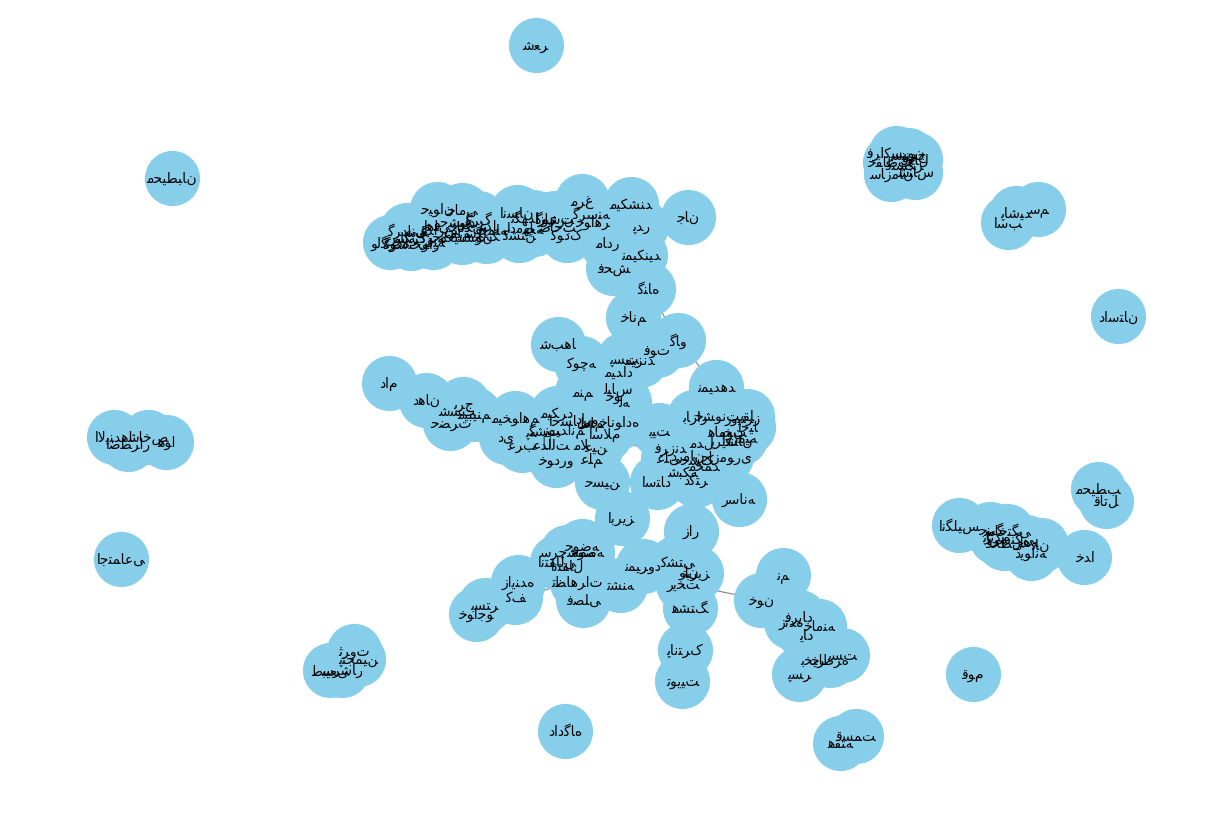

In [ ]:
df['list_of_lists'] = df['lemmatized_tweet'].apply(lambda x: x.split())
df['lemmatized_tweet'] = df['lemmatized_tweet'].apply(make_farsi_text)
# Train the Word2Vec model using the tokenized tweets
model = Word2Vec(df['list_of_lists'], vector_size=100, window=5, min_count=1, workers=4)

# Create an empty graph
graph = nx.Graph()
# Add nodes to the graph
for word in model.wv.index_to_key:
    graph.add_node(word)
# Add edges based on word similarities
for word in model.wv.index_to_key:
    similar_words = model.wv.most_similar(word)
    for sim_word, sim_score in similar_words:
        graph.add_edge(word, sim_word, weight=sim_score)

# Set the degree threshold for node filtering
degree_threshold =90
# Filter nodes based on degree
filtered_nodes = [node for node in graph.nodes if graph.degree(node) >= degree_threshold]

# Create a subgraph with filtered nodes and their neighbors
filtered_graph = graph.subgraph(filtered_nodes)

# Plot the filtered graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(filtered_graph, k=0.1)

# Specify a font that supports Persian characters
font = {'family': 'DejaVu Sans',
        'size': 10}
plt.rc('font', **font)

nx.draw(filtered_graph, pos, with_labels=True, node_color='skyblue', node_size=1500, font_size=10, edge_color='gray', width=0.8)
plt.show()

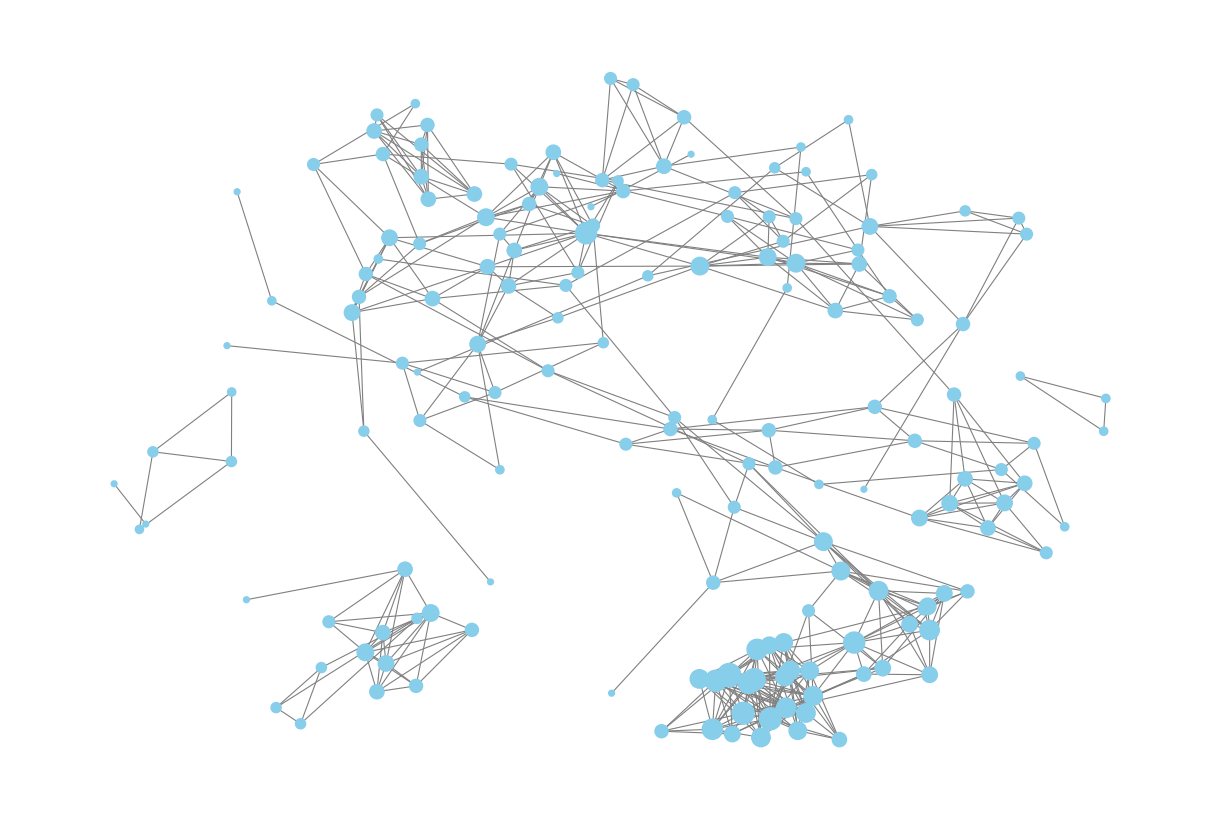

In [ ]:
# ... (previous code)

# Choose an appropriate layout and increase spacing
pos = nx.spring_layout(filtered_graph, k=0.3)

# Calculate node sizes based on degree centrality
degree_centrality = nx.degree_centrality(filtered_graph)
node_sizes = [3000 * degree_centrality[node] for node in filtered_graph.nodes]

# Create a dictionary to selectively label nodes
selected_labels = {node: node if degree_centrality[node] > 0.1 else '' for node in filtered_graph.nodes}

# Plot the filtered graph with adjusted parameters
plt.figure(figsize=(12, 8))
font = {'family': 'DejaVu Sans', 'size': 10}
plt.rc('font', **font)

nx.draw(filtered_graph, pos, with_labels=True, labels=selected_labels,
        node_color='skyblue', node_size=node_sizes, font_size=10, edge_color='gray', width=0.8)
plt.show()


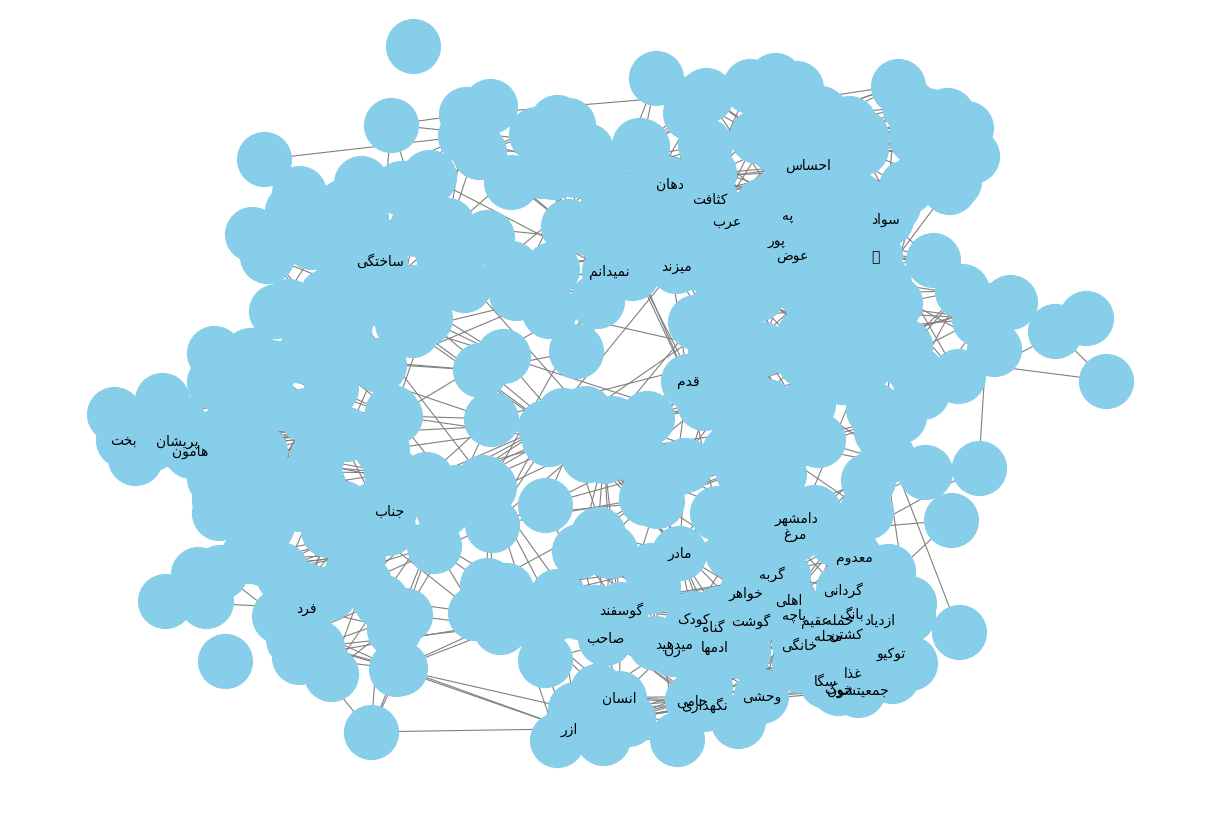

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from gensim.models import Word2Vec

# ... (previous code)

# Calculate degree centrality for each node
degree_centrality = nx.degree_centrality(filtered_graph)

# Define a threshold for degree centrality to determine which nodes to label
centrality_threshold = 0.03  # Adjust this threshold as needed

# Create a dictionary to selectively label nodes based on degree centrality
selected_labels = {node: node if degree_centrality[node] >= centrality_threshold else '' for node in filtered_graph.nodes}

# Plot the filtered graph with selective labeling
plt.figure(figsize=(12, 8))
font = {'family': 'DejaVu Sans', 'size': 10}
plt.rc('font', **font)

nx.draw(filtered_graph, pos, with_labels=True, labels=selected_labels,
        node_color='skyblue', node_size=1500, font_size=10, edge_color='gray', width=0.8)
plt.show()


تارگت ورد را هر دفعه برای هر موضوع باید تغییر داد


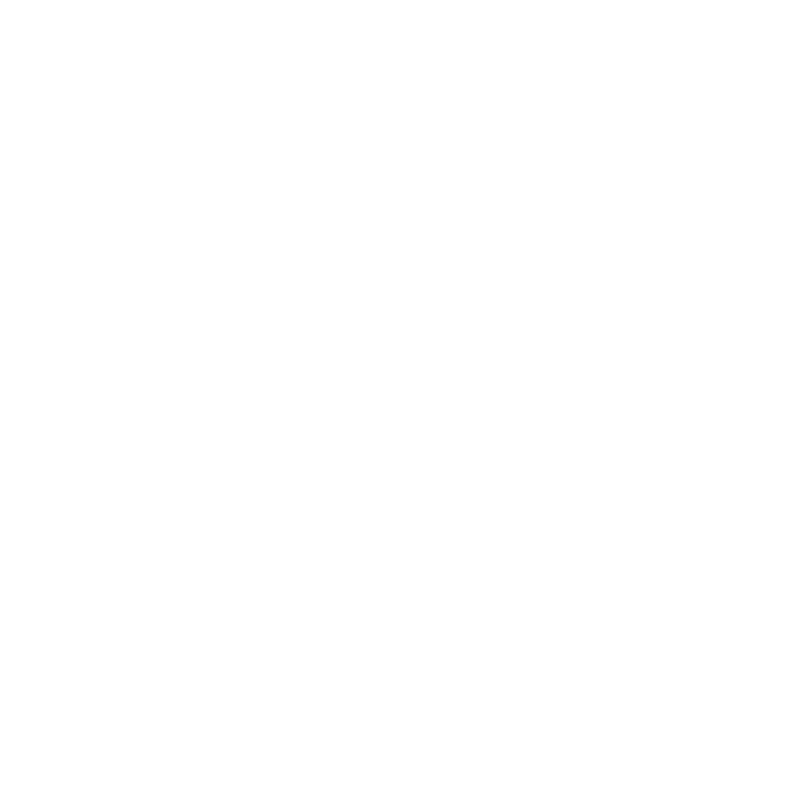

In [ ]:
df['tokenized_tweet'] = df['tokenized_tweet'].apply(make_farsi_text)
df['list_of_lists'] = df['tokenized_tweet'].apply(lambda x: x.split())
corpus = df['list_of_lists']

# Train Word2Vec model
model = Word2Vec(sentences=corpus, vector_size=100, window=10, min_count=1, workers=4)

def extract_associations(model, words, topn=5):
    associations = {}
    for word in words:
        if word in model.wv.key_to_index:
            sims = model.wv.most_similar(word, topn=topn)
            associated_words = [word2 for word2, sim in sims if word2 in model.wv.key_to_index]
            associations[word] = associated_words
    return associations


# Specify the words for which you want to extract associations
target_words = ['زاینده','کارون','اب']

# Extract associations
word_associations = extract_associations(model, target_words)

# Create the association graph
graph = nx.Graph()
for word, associated_words in word_associations.items():
    graph.add_node(word)
    for associated_word in associated_words:
        graph.add_node(associated_word)
        graph.add_edge(word, associated_word)

# Visualize the graph
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(graph)
nx.draw_networkx_nodes(graph, pos, node_size=500, node_color='lightblue')
nx.draw_networkx_edges(graph, pos, alpha=0.5)
nx.draw_networkx_labels(graph, pos, font_size=12, font_weight='bold')
plt.axis('off')
plt.show()

Some weights of BertModel were not initialized from the model checkpoint at HooshvareLab/bert-fa-zwnj-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3236 (\N{KANNADA LETTER TA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151

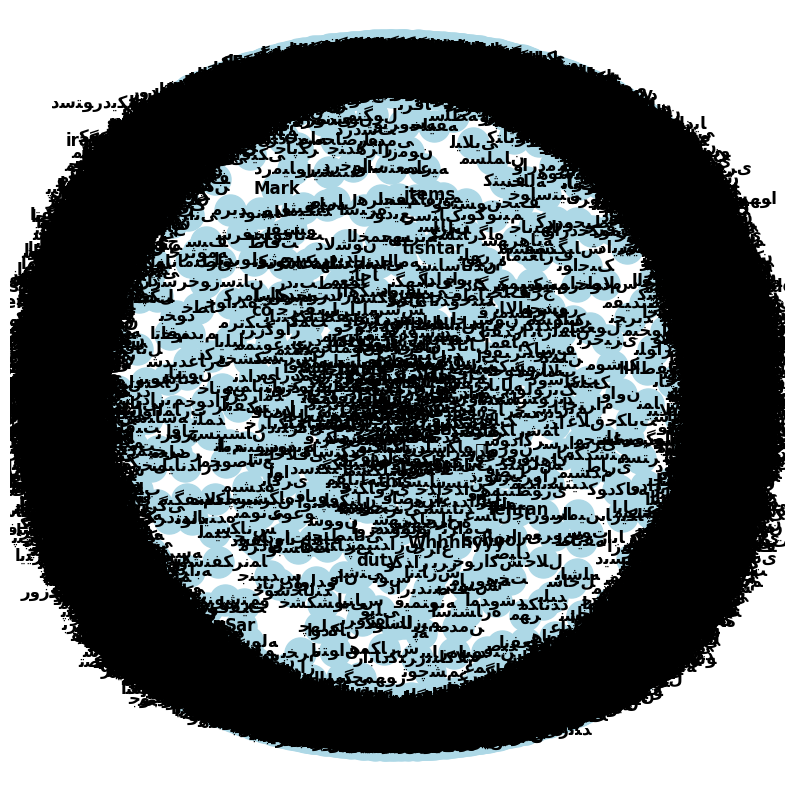

In [ ]:

# v3.0
model_name_or_path = "HooshvareLab/bert-fa-zwnj-base"
config = AutoConfig.from_pretrained(model_name_or_path)
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
model = AutoModel.from_pretrained(model_name_or_path)

df['list_of_lists'] = df['lemmatized_tweet'].apply(lambda x: x.split())
corpus = df['list_of_lists']

#corpus = df['tokenized_tweet']

# Train Word2Vec model
model = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=1, workers=4)

# Get word embeddings
word_embeddings = model.wv[model.wv.key_to_index]

# Perform dimensionality reduction
pca = PCA(n_components=2)
word_embeddings_2d = pca.fit_transform(word_embeddings)

# Cluster the word embeddings
kmeans = KMeans(n_clusters=4)
clusters = kmeans.fit_predict(word_embeddings)

# Create the word clustering graph
graph = nx.Graph()
for i, word in enumerate(model.wv.key_to_index):
    cluster = clusters[i]
    graph.add_node(word, cluster=cluster)

# Add edges between clusters based on shared words
def calculate_shared_words(cluster1, cluster2):
    if isinstance(cluster1, int) and isinstance(cluster2, int):
        cluster1 = [cluster1]
        cluster2 = [cluster2]
    shared_words = set(cluster1).intersection(set(cluster2))
    shared_words_count = len(shared_words)
    return shared_words_count


# Define the threshold value
threshold = 9  # adjust as per your needs

# Convert clusters array to list
clusters_list = clusters.tolist()

# Add edges between clusters based on shared words
for cluster1 in set(clusters_list):
    for cluster2 in set(clusters_list):
        if cluster1 != cluster2:
            shared_words_count = calculate_shared_words(cluster1, cluster2)  # Implement your shared words calculation method
            if shared_words_count > threshold:
                graph.add_edge(cluster1, cluster2)

# Visualize the graph
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(graph)
nx.draw_networkx_nodes(graph, pos, node_size=500, node_color='lightblue')
nx.draw_networkx_edges(graph, pos, alpha=0.5)
nx.draw_networkx_labels(graph, pos, font_size=12, font_weight='bold')
plt.axis('off')
plt.show()

**Clustering**

In [ ]:
print(df['tokenized_tweet'])

0                    ﻪﻠﺻﻮﺣ ﺭﺎﺒﻏ ﺩﺮﮔ ﻢﻨﯿﺒﯿﻣ ﺍﻮﻫ ﯽﯾﺍﺮﺸﺴﮐ ﻢﻬﺑ
1                         ﻩﺪﻋ ﯽﻄﺤﻗ ﺪﻨﻠﺑ ﺩﺭﺍﻭ ﺰﻣﺭ ﻢﻧﺎﺧ ﺪﺳﺮﭘ
2                             ﺵﺍﻭﺭﺎﮐ ﻢﯾﺭﻮﺨﯿﻣ ﯽﻟﺎﺴﮑﺸﺧ ﻥﺍﺮﺤﺑ
3        ﻥﺎﺘﺴﻣﺯ ﻞﺼﻓ ﺎﯿﻬﻣ ﯽﺘﺳﻭﺩ ﻝﺩ ﺭﺎﺒﻏ ﺩﺮﮔ ﻥﺎﮑﺗ ﺎﻬﻟﺩ ﺪﻧ...
4        ﺪﯿﯾﻮﮕﯿﻣ ﺮﺗﺰﯿﭼﺎﻧ ﻥﺎﻬﺟ ﻥﺍﺮﯾﺍ ﻢﯿﻠﻗﺍ ﻪﻧﺎﺨﻠﮔ ﯼﺎﻫﺯﺎﮔ...
                               ...                        
14200    ﯼﺯﺎﺠﻣ ﯼﺎﻀﻓ ﺵ ﺭﺎﺒﻏ ﺩﺮﮔ ﯼﺮﯾﻮﺼﺗ ﺵﻮﻣﺍﺮﻓ ﺮﻬﺷ ﺪﻧﺭﻮﺨﺑ...
14201                  ﻞﮕﻨﺟ ﻩﻮﮐ ﻑﺎﻔﺷ ﺵ ﺽﻮﻋ ﺭﺎﺒﻏ ﺩﺮﮔ ﻡﺯﻭﺮﻣﺍ
14202    ﯽﻠﻤﻋ ﻑﺍﺪﻫﺍ ﻕﺍﺯﺭﺍ ﯽﻄﺤﻗ ﺭﺍﺯﺎﺑ ﻝﺎﺳﺭﺍ ﺕﺮﯿﺼﺑ ﻥﺎﺘﺳﻭﺩ...
14203    ﻩﺩﺍﺭﺍ ﻡﺎﻈﻧ ﺖﺴﺑ ﻦﺑ ﯽﺸﯾﺎﻤﻧ ﯽﺘﻣﻮﮑﺣ ﯼﺎﻬﻧﺍﺮﺤﺑ ﻪﻠﺴﻠﺳ...
14204    ﮏﺷﻮﭘ ﯽﻄﺤﻗ ﻥﺎﺟ ﻪﭽﺑ ﺮﺨﺑ ﮏﺷﻮﭘ ﻪﺘﻓﺮﺸﯿﭘ ﻮﯿﮐﺭﺍ ﮎﻭﺎﻫ ...
Name: tokenized_tweet, Length: 14205, dtype: object


In [ ]:
preprocessed_tweets = [' '.join(tokens) for tokens in df['tokenized_tweet']]  # Convert list of lists to list of strings

# Feature extraction using TF-IDF
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(preprocessed_tweets)

# Dimensionality reduction using PCA
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features.toarray())

# Clustering using K-means
kmeans = KMeans(n_clusters=3)
cluster_labels = kmeans.fit_predict(reduced_features)

# Visualization
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=cluster_labels)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Cluster Visualization")
plt.show()

ValueError: ignored

In [ ]:

model_name_or_path = "HooshvareLab/bert-fa-zwnj-base"
config = AutoConfig.from_pretrained(model_name_or_path)
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)

# model = TFAutoModel.from_pretrained(model_name_or_path)  For TF
model = AutoModel.from_pretrained(model_name_or_path)

# Function to generate tweet vectors using BERT embeddings
def generate_tweet_vector(tokens):
    inputs = tokenizer.encode_plus(' '.join(tokens), padding='longest', max_length=128, truncation=True, return_tensors='pt')
    outputs = model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze().tolist()
    return embeddings

# Generate tweet vectors
df['TweetVectors'] = df['tokenized_tweet'].apply(generate_tweet_vector)

# Convert tweet vectors to a NumPy array
tweet_vectors = np.array(df['TweetVectors'].tolist())

# Perform clustering using K-means
kmeans = KMeans(n_clusters=3)  # Specify the desired number of clusters
clusters = kmeans.fit_predict(tweet_vectors)

# Assign the clusters to the DataFrame
df['Cluster'] = clusters
df.head(10)


Some weights of BertModel were not initialized from the model checkpoint at HooshvareLab/bert-fa-zwnj-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


KeyboardInterrupt: ignored

Visualize Clustering

In [ ]:
# Convert tweet vectors to a NumPy array
tweet_vectors = np.array(df['TweetVectors'].tolist())

# Perform clustering using K-means
kmeans = KMeans(n_clusters=3)  # Specify the desired number of clusters
clusters = kmeans.fit_predict(tweet_vectors)

# Assign the clusters to the DataFrame
df['Cluster'] = clusters

# Plot the clusters
plt.scatter(tweet_vectors[:, 0], tweet_vectors[:, 1], c=clusters, cmap='viridis')
plt.title('Clustering Visualization')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

**T-SNE**

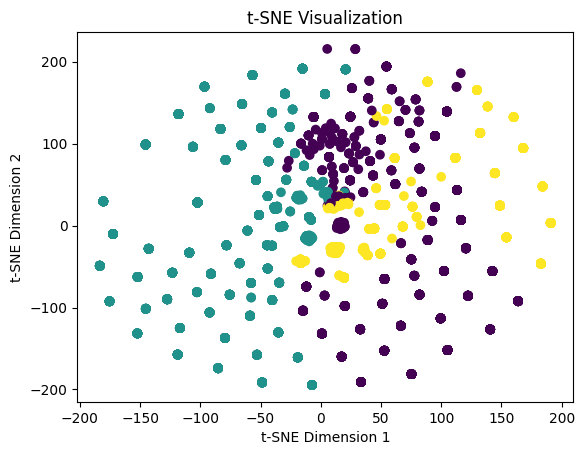

In [ ]:
# Convert tweet vectors to a NumPy array
tweet_vectors = np.array(df['TweetVectors'].tolist())

# Perform t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
embedded_vectors = tsne.fit_transform(tweet_vectors)

# Plot the embedded vectors
plt.scatter(embedded_vectors[:, 0], embedded_vectors[:, 1], c=clusters, cmap='viridis')
plt.title('t-SNE Visualization')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

**PCA**

In [ ]:
# Convert tweet vectors to a NumPy array
tweet_vectors = np.array(df['TweetVectors'].tolist())

# Perform PCA for dimensionality reduction
pca = PCA(n_components=2, random_state=42)
embedded_vectors = pca.fit_transform(tweet_vectors)

# Plot the embedded vectors
plt.scatter(embedded_vectors[:, 0], embedded_vectors[:, 1], c=clusters, cmap='viridis')
plt.title('PCA Visualization')
plt.xlabel('PCA Dimension 1')
plt.ylabel('PCA Dimension 2')
plt.show()

KeyError: ignored

Graph evaluation, metrics

In [ ]:
# Calculate graph-level metrics
num_nodes = len(graph.nodes)
num_edges = len(graph.edges)
avg_degree = sum(dict(graph.degree()).values()) / num_nodes
density = nx.density(graph)
clustering_coefficient = nx.average_clustering(graph)
assortativity = nx.degree_assortativity_coefficient(graph)
global_efficiency = nx.global_efficiency(graph)
avg_shortest_path = nx.average_shortest_path_length(graph)

# Create a dictionary to store the graph-level metrics
graph_metrics = {
    "Number of Nodes": num_nodes,
    "Number of Edges": num_edges,
    "Average Degree": avg_degree,
    "Density": density,
    "Clustering Coefficient": clustering_coefficient,
    "Assortativity": assortativity,
    "Global Efficiency": global_efficiency,
    "Average Shortest Path Length": avg_shortest_path
}

# Create a pandas DataFrame from the dictionary
graph_metrics_df = pd.DataFrame(graph_metrics, index=[0])

# Print the graph-level metrics table
print("Graph-Level Metrics:")
print(graph_metrics_df)

# Calculate node-level metrics
degree_centrality = nx.degree_centrality(graph)
betweenness_centrality = nx.betweenness_centrality(graph)
closeness_centrality = nx.closeness_centrality(graph)
eigenvector_centrality = nx.eigenvector_centrality(graph)
pagerank_centrality = nx.pagerank(graph)

# Create a dictionary to store the node-level metrics
node_metrics = {
    "Degree Centrality": degree_centrality,
    "Betweenness Centrality": betweenness_centrality,
    "Closeness Centrality": closeness_centrality,
    "Eigenvector Centrality": eigenvector_centrality,
    "PageRank Centrality": pagerank_centrality
}

# Create a pandas DataFrame from the dictionary
node_metrics_df = pd.DataFrame(node_metrics)

# Print the node-level metrics table
print("\nNode-Level Metrics:")
print(node_metrics_df)


/usr/local/lib/python3.10/dist-packages/networkx/algorithms/assortativity/mixing.py:207: RuntimeWarning: invalid value encountered in divide
  a = a / a.sum()


NetworkXError: ignored

In [ ]:
node_metrics_df.head()

#**Feature weight**

In [ ]:
# v3.0
model_name_or_path = "HooshvareLab/bert-fa-zwnj-base"
config = AutoConfig.from_pretrained(model_name_or_path)
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
model = AutoModel.from_pretrained(model_name_or_path)
# Step 2: Bag-of-Words representation
count_vectorizer = CountVectorizer(stop_words='english', max_features=1000)  # You can adjust max_features as needed
bow_matrix = count_vectorizer.fit_transform(df['tokenized_tweet'])

# Get feature names from CountVectorizer
feature_names = count_vectorizer.get_feature_names_out()

# Step 3: TF-IDF weighting
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)  # You can adjust max_features as needed
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tokenized_tweet'])

# Extract the feature weights from TF-IDF vectorizer
feature_weights = tfidf_vectorizer.idf_

# Fill the 'Feature_Weight' column with the extracted feature weights
df['Feature_Weight'] = 0.0  # Initialize with a placeholder value

df['Feature_Weight'] = feature_weights

Some weights of BertModel were not initialized from the model checkpoint at HooshvareLab/bert-fa-zwnj-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ValueError: ignored

Dataset dimensions: (6014, 17)
Sample rows:
   Column1            ID              Date  \
0    20001  1.460000e+18  11/20/2021 19:56   
1    20002  1.460000e+18  11/20/2021 19:55   
2    20004  1.460000e+18  11/20/2021 19:55   
3    20006  1.460000e+18  11/20/2021 19:53   
4    20007  1.460000e+18  11/20/2021 19:53   

                                               Tweet  \
0  @Kamiabrostami اگ واسه چند روز آب و انداختن تو...   
1  @zurnazan @yazdahoom برای اینکه مردم رفتن تو ز...   
2  @Kamiabrostami مثلا چیکار باید میکردیم؟؟؟ وقتی...   
3  مطالبه گری و وحدت در ظلم ستیزی تنها راه مبارزه...   
4  @FarsNews_Agency @hesamodin1 با "دستور" زاینده...   

                                                 URL  Likes  Retweet  Replies  \
0  https://twitter.com/lifearoundme96/status/1462...      0        0        1   
1  https://twitter.com/ArshiaNa2004/status/146209...      0        0        0   
2  https://twitter.com/lifearoundme96/status/1462...      0        0        1   
3  https://twitter

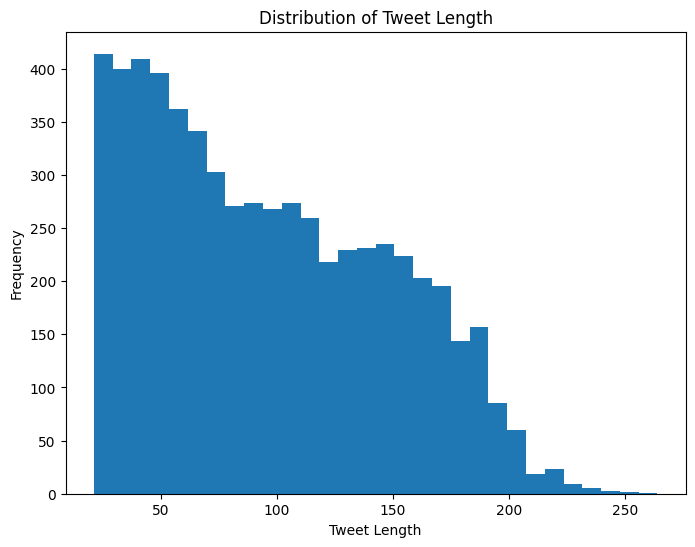

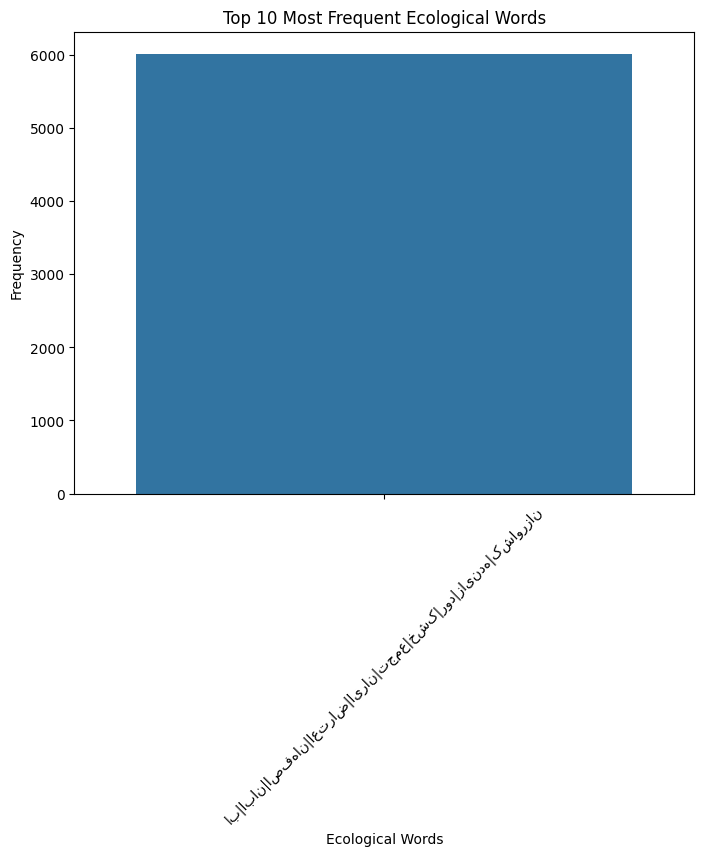

KeyError: ignored

<Figure size 800x600 with 0 Axes>

In [ ]:

# Basic Data Exploration
print("Dataset dimensions:", df.shape)
print("Sample rows:")
print(df.head())

# Statistical Summary
print("Statistical summary:")
print(df.describe())

# Data Visualization
# Histogram of tweet lengths
df['Tweet_Length'] = df['FormalTweet'].apply(len)
plt.figure(figsize=(8, 6))
plt.hist(df['Tweet_Length'], bins=30)
plt.xlabel('Tweet Length')
plt.ylabel('Frequency')
plt.title('Distribution of Tweet Length')
plt.show()

# Combine all the tweets into a single text
all_text = ' '.join(df['FormalTweet'])

# Tokenize the text using a CountVectorizer
count_vectorizer = CountVectorizer(stop_words='english', max_features=10)  # Change max_features as needed
word_counts = count_vectorizer.fit_transform([all_text])

# Get the most frequent words
most_frequent_words = count_vectorizer.get_feature_names_out()

# Fill the 'Ecological' column with the most frequent words
most_frequent_words_str = '|'.join(most_frequent_words)
df['Ecological'] = most_frequent_words_str

# Bar chart of most frequent ecological words
word_counts = df['Ecological'].value_counts().head(10)
plt.figure(figsize=(8, 6))
sns.barplot(x=word_counts.index, y=word_counts.values)
plt.xlabel('Ecological Words')
plt.ylabel('Frequency')
plt.title('Top 10 Most Frequent Ecological Words')
plt.xticks(rotation=45)
plt.show()

# Box plot of feature weights
plt.figure(figsize=(8, 6))
sns.boxplot(data=df['Feature_Weight'])
plt.ylabel('Feature Weight')
plt.title('Box Plot of Feature Weights')
plt.show()

# Word Cloud of ecological words
text = ' '.join(df['Ecological'])
persian_font_path = "/content/drive/MyDrive/arial.ttf"  # Replace with the path to a font file that supports Persian characters
wordcloud = WordCloud(width=800, height=400, background_color='white', font_path=persian_font_path).generate(text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Ecological Words')
plt.show()

# Correlation Analysis
correlation_matrix = df[['Feature_Weight', 'Likes']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


#**Feature Selection**

In [ ]:
# v3.0
model_name_or_path = "HooshvareLab/bert-fa-zwnj-base"
config = AutoConfig.from_pretrained(model_name_or_path)
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
model = AutoModel.from_pretrained(model_name_or_path)

# Get the number of features to match the length of the DataFrame
max_features = len(df)

# Step 2: Bag-of-Words representation
count_vectorizer = CountVectorizer(stop_words='english', max_features=max_features)
bow_matrix = count_vectorizer.fit_transform(df['tokenized_tweet'])

# Get feature names from CountVectorizer
feature_names = count_vectorizer.get_feature_names_out()

# Step 3: TF-IDF weighting
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=max_features)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tokenized_tweet'])

# Extract the feature weights from TF-IDF vectorizer
feature_weights = tfidf_vectorizer.idf_

# Fill the 'Feature_Weight' column with the extracted feature weights
df['Feature_Weight'] = feature_weights



# Combine all the tweets into a single text
all_text = ' '.join(df['lemmatized_tweet'])

# Tokenize the text using a CountVectorizer
count_vectorizer = CountVectorizer(stop_words='english', max_features=10)  # Change max_features as needed
word_counts = count_vectorizer.fit_transform([all_text])

# Get the most frequent words
most_frequent_words = count_vectorizer.get_feature_names_out()

# Fill the 'Ecological' column with the most frequent words
most_frequent_words_str = '|'.join(most_frequent_words)
df['Ecological'] = most_frequent_words_str



# Assuming 'Target_Column' is the name of the target variable column
X = tfidf_matrix  # Features
y = df['tokenized_tweet']  # Target variable#######################################################

# Perform chi-square test for feature selection
k_best = 10  # Select the top 10 features
selector = SelectKBest(score_func=chi2, k=k_best)
X_selected = selector.fit_transform(X, y)

# Get the selected feature names
selected_feature_names = [feature_names[i] for i in selector.get_support(indices=True)]

# Display the selected feature names
print("Selected Features:", selected_feature_names)


Some weights of BertModel were not initialized from the model checkpoint at HooshvareLab/bert-fa-zwnj-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Selected Features: ['hac', 'km', 'ﺎﮐﺎﻣ', 'ﺏﺎﻬﺘﯿﮔ', 'ﺪﯾﺪﻧﺎﮑﺸﺧ', 'ﺪﻨﯾﻮﮕﻧ', 'ﺭﺎﺘﮑﻫﺭﺍﺰﻫ', 'ﺶﻨﯾﺮﮑﺳﺍ', 'ﻢﯿﻟﺎﯿﺧ', 'ﻮﯾﺎﮐﺎﮐﺮﯿﺷ']


**Feature Importance from Trees**

خروجی این چند کد باید بصورت مقایسه‌ای آورده شوند

In [ ]:
import pandas as pd
import random

# Load your dataset into a DataFrame


# Specify the number of random records you want to select
num_records_to_select = 10  # Adjust this number as needed

# Use random.sample to select random indices from the dataset
random_indices = random.sample(range(len(df)), num_records_to_select)

# Use iloc to retrieve the randomly selected records
random_records = df.iloc[random_indices]

# Now, 'random_records' contains your randomly selected records
print(random_records)


In [ ]:

# v3.0
model_name_or_path = "HooshvareLab/bert-fa-zwnj-base"
config = AutoConfig.from_pretrained(model_name_or_path)
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
model = AutoModel.from_pretrained(model_name_or_path)

# Create the TF-IDF vectorizer and calculate the TF-IDF matrix
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)  # You can adjust max_features as needed
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tokenized_tweet'])

# Assuming 'Target_Column' is the name of the target variable column
X = tfidf_matrix  # Features
y = df['tokenized_tweet']  # Target variable (replace 'Target_Column' with the actual name)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier on the training data
rf_classifier.fit(X_train, y_train)

# Get feature importances from the trained Random Forest model
feature_importances = rf_classifier.feature_importances_

# Create a DataFrame to store the feature names and their importances
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importance ranking
print(feature_importance_df)

Some weights of BertModel were not initialized from the model checkpoint at HooshvareLab/bert-fa-zwnj-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Gradient Boosting Feature Importance

In [ ]:
# v3.0
model_name_or_path = "HooshvareLab/bert-fa-zwnj-base"
config = AutoConfig.from_pretrained(model_name_or_path)
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
model = AutoModel.from_pretrained(model_name_or_path)

# Create the TF-IDF vectorizer and calculate the TF-IDF matrix
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)  # You can adjust max_features as needed
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tokenized_tweet'])

# Assuming 'Target_Column' is the name of the target variable column
X = tfidf_matrix  # Features
y = df['tokenized_tweet']  # Target variable (replace 'Target_Column' with the actual name)


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Gradient Boosting classifier
gb_classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train the classifier on the training data
gb_classifier.fit(X_train, y_train)

# Get feature importances from the trained Gradient Boosting model
feature_importances = gb_classifier.feature_importances_

# Create a DataFrame to store the feature names and their importances
feature_importance_df = pd.DataFrame({'Feature': list(X.columns), 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importance ranking
print(feature_importance_df)


In [ ]:
# v3.0
model_name_or_path = "HooshvareLab/bert-fa-zwnj-base"
config = AutoConfig.from_pretrained(model_name_or_path)
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
model = AutoModel.from_pretrained(model_name_or_path)

# Create the TF-IDF vectorizer and calculate the TF-IDF matrix
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)  # You can adjust max_features as needed
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tokenized_tweet'])

# Assuming 'Target_Column' is the name of the target variable column
X = tfidf_matrix  # Features
y = df['tokenized_tweet']  # Target variable (replace 'Target_Column' with the actual name)

# Create a Logistic Regression classifier
logreg_classifier = LogisticRegression()

# Create the RFE selector with the Logistic Regression model
num_features_to_select = 10  # Number of features to select (you can adjust this as needed)
rfe_selector = RFE(estimator=logreg_classifier, n_features_to_select=num_features_to_select, step=1)

# Fit the RFE selector on the data
rfe_selector.fit(X, y)

# Get the selected features
selected_feature_indices = rfe_selector.support_
selected_feature_names = [feature_names[i] for i, is_selected in enumerate(selected_feature_indices) if is_selected]

# Display the selected feature names
print("Selected Features:", selected_feature_names)


L1 Regularization (Lasso)

In [ ]:
# v3.0
model_name_or_path = "HooshvareLab/bert-fa-zwnj-base"
config = AutoConfig.from_pretrained(model_name_or_path)
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
model = AutoModel.from_pretrained(model_name_or_path)


max_features = len(df)
# Create the TF-IDF vectorizer and calculate the TF-IDF matrix
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=max_features)  # You can adjust max_features as needed
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tokenized_tweet'])

# Extract the feature weights from TF-IDF vectorizer
feature_weights = tfidf_vectorizer.idf_

# Assuming 'Target_Column' is the name of the column where you want to store the feature weights
df['Target_Column'] = feature_weights

# Assuming 'Target_Column' is the name of the target variable column
X = tfidf_matrix  # Features
y = df['Target_Column']  # Target variable (replace 'Target_Column' with the actual name)

# Create the Lasso model
lasso_model = Lasso(alpha=0.001)  # 'alpha' is the regularization strength, you can adjust it as needed

# Fit the Lasso model on the data
lasso_model.fit(X, y)

# Get the coefficients (weights) of the features
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = lasso_model.coef_

# Create a DataFrame to store the feature names and their coefficients
feature_coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Filter out features with coefficient zero (not selected by Lasso)
selected_features = feature_coeff_df[feature_coeff_df['Coefficient'] != 0]

# Display the selected features
print("Selected Features:", selected_features)


In [ ]:
# v3.0
model_name_or_path = "HooshvareLab/bert-fa-zwnj-base"
config = AutoConfig.from_pretrained(model_name_or_path)
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
model = AutoModel.from_pretrained(model_name_or_path)

max_features = len(df)

# Create a bag-of-words representation
vectorizer = CountVectorizer(max_features=max_features)  # You can adjust max_features as needed
bow_matrix = vectorizer.fit_transform(df['tokenized_tweet'])

# Get the feature names
feature_names = vectorizer.get_feature_names_out()

# Check the vocabulary size
print("Vocabulary Size:", len(feature_names))

# Convert the bag-of-words matrix to gensim format
corpus = gensim.matutils.Sparse2Corpus(bow_matrix.T)

# Build the LDA model
num_topics = 5  # Number of topics to identify (you can adjust this)
lda_model = models.LdaModel(corpus=corpus, num_topics=num_topics, id2word=dict(enumerate(feature_names)))

# Get the topics and their corresponding keywords
topics = lda_model.print_topics(num_words=10)

# Display the topics and their keywords
for topic in topics:
    print(topic)

coherence scoring and Dendrogram chart

In [ ]:
###########coherence scoring##################

# Assuming 'corpus' is your document-term matrix and 'id2word' is your dictionary
# Train LDA model
lda_model = LdaModel(corpus=corpus, id2word=id2word, num_topics=5)  # Adjust the number of topics

# Calculate coherence scores
coherence_score_cv = CoherenceModel(model=lda_model, texts=your_texts, dictionary=id2word, coherence='c_v')
coherence_score_umass = CoherenceModel(model=lda_model, texts=your_texts, dictionary=id2word, coherence='u_mass')

print("Coherence Score (C_V):", coherence_score_cv.get_coherence())
print("Coherence Score (U_Mass):", coherence_score_umass.get_coherence())

In [ ]:

# Sample hierarchical topic structure (you should replace this with your actual data)
# Assume 'topics' is a list of topic vectors, each vector representing a topic's word distribution
# For simplicity, we use randomly generated data as a placeholder
np.random.seed(0)
topics = np.random.rand(10, 20)  # 10 topics with 20 words each

# Calculate linkage matrix using Ward linkage method
linkage_matrix = linkage(topics, method='ward')

# Create a dendrogram
plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
dendrogram(linkage_matrix)

# Label the topics (replace 'topic_labels' with your own topic labels)
topic_labels = [f"Topic {i}" for i in range(1, len(topics) + 1)]
plt.xticks(range(1, len(topics) + 1), topic_labels, rotation=45)

# Add title and labels
plt.title('Hierarchical Topic Dendrogram')
plt.xlabel('Topics')
plt.ylabel('Distance')

# Show the dendrogram
plt.tight_layout()
plt.show()

#**Attributed Graph**

In [ ]:
from hazm import *
tagger = POSTagger(model='/content/pos_tagger.model')

def tokenize_and_tag(text):
    #normalized_text = normalizer.normalize(text)
    #tokens = word_tokenize(normalized_text)
    tagged_tokens = tagger.tag(text)
    return tagged_tokens

df['tagged_tokens'] = df['tokenized_tweet'].apply(tokenize_and_tag)

# Create an empty graph
graph = nx.Graph()

# Add nodes for tweets and users
for index, row in df.iterrows():
    tweet_id = row['Column1']
    user_id = row['ID']
    graph.add_node(tweet_id, node_type='tweet', content=row['FormalTweet'])
    graph.add_node(user_id, node_type='user', username=row['ID'])

    # Extract mentions using regular expressions
    mentions = re.findall(r'@(\w+)', row['FormalTweet'])
    for mention in mentions:
        graph.add_node(mention, node_type='user', username=mention)
        graph.add_edge(tweet_id, mention, relationship='mention')

In [ ]:
# You can extract additional attributes from your dataset and add them to the nodes and edges in the graph
# For example, if you have a 'timestamp' column in your dataset:
for index, row in df.iterrows():
    tweet_id = row['Column1']
    graph.nodes[tweet_id]['Date'] = row['Date']

In [ ]:
import pandas as pd
import re
from hazm import word_tokenize, Normalizer, POSTagger, word_tokenize
import networkx as nx

# Assuming your dataset is in a CSV file named 'Persian water.csv'
#df = pd.read_csv('stemmed_dataset.csv')

# Data cleaning
def clean_tweet(tweet):
    # Remove URLs and special characters
    cleaned_tweet = re.sub(r'http\S+|[^آ-ی۰-۹ ]', '', tweet)
    return cleaned_tweet

#df['cleaned_tweet'] = df['Tweet'].apply(clean_tweet)

# Tokenization and POS tagging
#normalizer = Normalizer()
tagger = POSTagger(model='/content/pos_tagger.model')

def tokenize_and_tag(text):
    normalized_text = normalizer.normalize(text)
    tokens = word_tokenize(normalized_text)
    tagged_tokens = tagger.tag(tokens)
    return tagged_tokens

#df['tagged_tokens'] = df['cleaned_tweet'].apply(tokenize_and_tag)

# Create an empty graph
graph = nx.Graph()

# Add nodes for tweets and users
for index, row in df.iterrows():
    tweet_id = row['Column1']
    user_id = row['ID']
    graph.add_node(tweet_id, node_type='tweet', content=row['FormalTweet'])
    graph.add_node(user_id, node_type='user', username=row['ID'])

    # Extract mentions using regular expressions
    mentions = re.findall(r'@(\w+)', row['FormalTweet'])
    for mention in mentions:
        graph.add_node(mention, node_type='user', username=mention)
        graph.add_edge(tweet_id, mention, relationship='mention')

    # Add tweet date as an attribute to the tweet node
    graph.nodes[tweet_id]['Date'] = row['Date']


In [ ]:
#have already created the graph (previous code)

# Plot the graph
pos = nx.spring_layout(graph, seed=42)  # Adjust the layout algorithm as needed
node_labels = nx.get_node_attributes(graph, 'username')
edge_labels = nx.get_edge_attributes(graph, 'relationship')

# Draw nodes
nx.draw_networkx_nodes(graph, pos, node_color='lightblue', node_size=20, alpha=0.9)

# Draw edges
nx.draw_networkx_edges(graph, pos, edge_color='gray', alpha=0.9)

# Draw node labels
nx.draw_networkx_labels(graph, pos, labels=node_labels, font_size=10, font_color='black')

# Draw edge labels
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=8, font_color='red')

# Display the graph
plt.axis('off')  # Turn off axis for a cleaner visualization
plt.show()

do it with different layout

In [ ]:

# ... Assuming you've already created the graph

# Plot the graph with a random layout
pos = nx.random_layout(graph, seed=42)  # Use random_layout for a random node placement
node_labels = nx.get_node_attributes(graph, 'username')
edge_labels = nx.get_edge_attributes(graph, 'relationship')

# Reduce node size
nx.draw_networkx_nodes(graph, pos, node_color='lightblue', node_size=100, alpha=0.7)

# Reduce edge opacity
nx.draw_networkx_edges(graph, pos, edge_color='gray', alpha=0.4)

# Draw node labels
nx.draw_networkx_labels(graph, pos, labels=node_labels, font_size=8, font_color='black')

# Draw edge labels
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=6, font_color='red')

# Display the graph
plt.axis('off')  # Turn off axis for a cleaner visualization
plt.show()

NER Recognition

In [ ]:
# Load ParsBERT tokenizer and model for NER
model_name = "HooshvareLab/bert-base-parsbert-ner-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)


In [ ]:
data['named_entities'] = data['FormalTweet'].apply(lambda text: [(token, model.config.id2label[pred]) for token, pred in zip(tokenizer(text, return_tensors="pt")["input_ids"][0], model(**tokenizer(text, return_tensors="pt")).logits.argmax(-1).squeeze().tolist()) if model.config.id2label[pred] != "O"])
# Decode token IDs back to words for each named entity in the 'named_entities' column
data['decoded_entities'] = data['named_entities'].apply(lambda entities: [(tokenizer.decode(token), label) for token, label in entities])

# Check the first few rows with the decoded named entities
print(data['decoded_entities'])

In [ ]:
# Function to extract cities from the named entities
def extract_cities_from_named_entities(named_entities):
    cities = [token for token, label in named_entities if label == 'B-location']
    return cities

# Apply city extraction to the 'named_entities' column
data['cities'] = data['named_entities'].apply(extract_cities_from_named_entities)

# Check the first few rows with the extracted cities
print(data.head())


In [ ]:
#############Keyword Extraction###########
# Initialize the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=10, stop_words=stopwords) #*********ئش

# Fit and transform the vectorizer to the tweet text
tfidf_matrix = tfidf_vectorizer.fit_transform(data['FormalTweet'].tolist())

# Get the feature names (keywords)
keywords = tfidf_vectorizer.get_feature_names_out()

print("Keywords:", keywords)


In [ ]:

# Analyzing city mentions in the tweets
city_freq = data['cities'].explode().value_counts()

# Plotting the frequency of cities mentioned in the tweets
plt.figure(figsize=(10, 6))
city_freq.plot(kind='bar', color='skyblue')
plt.title('Cities Mentioned in Tweets about Environmental Issues')
plt.xlabel('City')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# Analyzing keyword frequency in the tweets
keyword_freq = tfidf_matrix.sum(axis=0).A1
keywords_with_freq = sorted(list(zip(keywords, keyword_freq)), key=lambda x: x[1], reverse=True)

# Plotting the top keywords mentioned in the tweets
plt.figure(figsize=(10, 6))
plt.bar([kw[0] for kw in keywords_with_freq], [kw[1] for kw in keywords_with_freq], color='lightgreen')
plt.title('Top Keywords Mentioned in Tweets about Environmental Issues')
plt.xlabel('Keywords')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Analyzing city mentions in the tweets
city_freq = data['cities'].explode().value_counts()

# Choose the number of top cities to plot
top_n_cities = 10

# Select the top N cities with the highest frequencies
top_city_freq = city_freq.head(top_n_cities)

# Get the decoded city names from 'decoded_entities' column
decoded_city_names = data['decoded_entities'].explode().tolist()

# Plotting the frequency of top cities mentioned in the tweets
plt.figure(figsize=(10, 6))
top_city_freq.plot(kind='bar', color='skyblue')
plt.title(f'Top {top_n_cities} Cities Mentioned in Tweets about Environmental Issues')
plt.xlabel('City')
plt.ylabel('Frequency')
plt.xticks(range(len(decoded_city_names[:top_n_cities])), decoded_city_names[:top_n_cities], rotation=45)
plt.show()


**Sentment Analysis**

In [ ]:
# Load the sentiment analysis model
sentiment_analyzer = pipeline('sentiment-analysis', model='HooshvareLab/bert-fa-base-uncased-sentiment-deepsentipers-multi')


In [ ]:
# Function to perform sentiment analysis on a given text
def perform_sentiment_analysis(text):
    result = sentiment_analyzer(text)
    sentiment_label = result[0]['label']
    confidence_score = result[0]['score']
    return sentiment_label, confidence_score

# Apply sentiment analysis to the 'tweet_text' column
data['sentiment_label'], data['confidence_score'] = zip(*data['lemmatized_tweet'].apply(perform_sentiment_analysis))

# Check the first few rows with sentiment analysis results
print(data.head())

#**Data Analysis**

In [ ]:
# Analyzing sentiment distribution
sentiment_distribution = data['sentiment_label'].value_counts()

# Plotting sentiment distribution
plt.figure(figsize=(6, 4))
sentiment_distribution.plot(kind='bar', color='lightblue')
plt.title('Sentiment Distribution in Tweets')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Explode the 'cities' column to create separate rows for each city
data_exploded = data.explode('cities')


top_n_cities = 10
# Analyzing sentiment by cities
sentiment_by_city = data_exploded.groupby('cities')['sentiment_label'].value_counts().unstack().fillna(0)

# Plotting sentiment analysis by cities
plt.figure(figsize=(10, 6))
sentiment_by_city.plot(kind='bar', stacked=True)
plt.title('Sentiment Analysis by Cities')
plt.xlabel('City')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment Label', loc='upper right')
plt.xticks(rotation=45)
plt.show()


In [ ]:
#خروجی این قسمت را با خروجی دو قسمت پایینتر  باهم بیاورم در داکیومنت ######################
# Filter data to include only tweets with the top sentiment label
top_sentiment_label = 'furious'  # Change this to the label you want to explore (e.g., 'LABEL_0', 'LABEL_1', 'LABEL_2')
tweets_with_top_sentiment = data[data['sentiment_label'] == top_sentiment_label]

# Analyzing top keywords in tweets with the top sentiment
top_keyword_freq = tfidf_vectorizer.fit_transform(tweets_with_top_sentiment['lemmatized_tweet']).sum(axis=0).A1
top_keywords_with_freq = sorted(list(zip(keywords, top_keyword_freq)), key=lambda x: x[1], reverse=True)[:10]

# Plotting the top keywords in tweets with the top sentiment
plt.figure(figsize=(10, 6))
plt.bar([kw[0] for kw in top_keywords_with_freq], [kw[1] for kw in top_keywords_with_freq], color='lightgreen')
plt.title(f'Top Keywords in Tweets with {top_sentiment_label} Sentiment')
plt.xlabel('Keywords')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


In [ ]:
############خروجی این قسمت با خروجی دو قسمت قبل باهم در داکیومنت آورده شود ##########

# Assuming you have already calculated the top_keywords_with_freq and sentiment_by_city dataframes
# Filter data to include only tweets with the top sentiment label
top_sentiment_label = 'furious'  # Change this to the label you want to explore (e.g., 'LABEL_0', 'LABEL_1', 'LABEL_2')
tweets_with_top_sentiment = data[data['sentiment_label'] == top_sentiment_label]

# Analyzing top keywords in tweets with the top sentiment
top_keyword_freq = tfidf_vectorizer.fit_transform(tweets_with_top_sentiment['lemmatized_tweet']).sum(axis=0).A1
top_keywords_with_freq = sorted(list(zip(keywords, top_keyword_freq)), key=lambda x: x[1], reverse=True)[:10]


In [ ]:
# Assuming you have already calculated the sentiment_by_city dataframe and top_keywords_with_freq list

# Create the top_keywords_with_freq dataframe and handle duplicates
top_keywords_with_freq_df = pd.DataFrame(top_keywords_with_freq, columns=['Keyword', 'Frequency'])
top_keywords_with_freq_df = top_keywords_with_freq_df.drop_duplicates(subset='Keyword', keep='first')

# Convert any tensors in the 'cities' column to strings
data['cities'] = data['cities'].apply(lambda x: ', '.join(x.numpy().tolist()) if isinstance(x, torch.Tensor) else x)

# Aggregate sentiment counts by city and sentiment label
sentiment_by_city_agg = data.groupby(['cities', 'sentiment_label']).size().unstack(fill_value=0)

# Join sentiment_by_city_agg and top_keywords_with_freq_df dataframes on the 'Keyword' column
keywords_sentiment_city = sentiment_by_city_agg.join(top_keywords_with_freq_df.set_index('Keyword'))

# Calculate the correlation between cities and keywords
correlation_df = keywords_sentiment_city.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
plt.imshow(correlation_df, cmap='coolwarm', interpolation='nearest', aspect='auto')
plt.title('Correlation between Cities and Keywords')
plt.xticks(range(correlation_df.shape[1]), correlation_df.columns, rotation=45, ha='right')
plt.yticks(range(correlation_df.shape[0]), correlation_df.index)
plt.colorbar()
plt.show()


#**Recommender System**

Run it with all dataset

In [ ]:
# Replace this list with your ecological words
ecological_words = ['آلودگی', 'اقلیم', 'پایداری', 'هوا', 'اب']#####


# Create a DataFrame with individual city names in the 'cities' column
data_individual_cities = data.explode('cities')

# Get all unique cities from the dataset
all_cities = data_individual_cities['cities'].unique()

# Filter data to include only the tweets from the unique cities
data_all_cities = data_individual_cities[data_individual_cities['cities'].isin(all_cities)]

# Function to recommend the city most related to a given word
def recommend_city_for_word(word):
    word_presence = []
    for city in all_cities:
        city_tweets = data_all_cities[data_all_cities['cities'] == city]['lemmatized_tweet']
        word_presence.append(int(any(word.lower() in tweet.lower() for tweet in city_tweets)))
    word_correlation = pd.Series(word_presence, index=all_cities)
    recommended_city_id = word_correlation.idxmax()
    recommended_city_name = data_all_cities[data_all_cities['cities'] == recommended_city_id]['decoded_entities'].iloc[0]
    return recommended_city_name

# Test the function with a word
word_to_recommender = 'تخریب'
recommended_city = recommend_city_for_word(word_to_recommender)
print(f"The city most related to the word '{word_to_recommender}' is: {recommended_city}")

In [ ]:
# Load the sentiment analysis model
sentiment_analyzer = pipeline('sentiment-analysis', model='HooshvareLab/bert-fa-base-uncased-sentiment-deepsentipers-multi')

# Function to perform sentiment analysis on a given text
def perform_sentiment_analysis(text):
    result = sentiment_analyzer(text)
    sentiment_label = result[0]['label']
    confidence_score = result[0]['score']
    return sentiment_label, confidence_score

# Apply sentiment analysis to the 'tweet_text' column
data['sentiment_label'], data['confidence_score'] = zip(*data['lemmatized_tweet'].apply(perform_sentiment_analysis))

# Check the first few rows with sentiment analysis results
print(data.head())



In [ ]:
from sklearn.pipeline import Pipeline

# Sample dataset of Persian tweets about environmental issues
tweets = data['lemmatized_tweet'].tolist()
sentiments = data['sentiment_label'].tolist()
# Data Preprocessing: Clean the tweets and tokenize the text
normalized_tweets = df['fully_cleaned_text']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    normalized_tweets, sentiments, test_size=0.2, random_state=42
)

# Convert the tokenized text back to strings for TF-IDF vectorization
X_train_str = [' '.join(tokens) for tokens in X_train]
X_test_str = [' '.join(tokens) for tokens in X_test]

# Build a Naive Bayes classifier using TF-IDF vectorization
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

# Train the classifier on the training data
pipeline.fit(X_train_str, y_train)

# Make predictions on the test data
y_pred = pipeline.predict(X_test_str)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print(classification_report(y_test, y_pred))

In [ ]:
# Function to clean the tweets and tokenize the text
def preprocess_tweets(tweets):
    normalized_tweets = []
    normalizer = hazm.Normalizer()
    for tweet in tweets:
        # Normalize the text
        normalized_tweet = normalizer.normalize(tweet)
        # Tokenize the text
        tokens = hazm.word_tokenize(normalized_tweet)
        normalized_tweets.append(tokens)
    return normalized_tweets

# Sample dataset of Persian tweets about environmental issues
tweets = data['lemmatized_tweet'].tolist()

# Apply data preprocessing to the dataset
normalized_tweets = df['fully_cleaned_text']

# Function to calculate sentiment using TextBlob
def get_sentiment_score(text):
    blob = TextBlob(' '.join(text))
    return blob.sentiment.polarity

# Calculate sentiment for each tweet
sentiment_scores = [get_sentiment_score(tokens) for tokens in normalized_tweets]

# Add the sentiment scores to the DataFrame
data['sentiment_score'] = sentiment_scores

# Function to determine the overall sentiment label based on sentiment scores
def get_sentiment_label(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

# Add a new column for the overall sentiment label
data['overall_Sentiment'] = data['sentiment_score'].apply(get_sentiment_label)

# Function to get sentiment and details for tweets on a given date
def get_sentiment_and_details_for_date(date, tweets_data):
    # Filter tweets for the given date
    tweets_on_date = tweets_data[tweets_data['Date'].str.startswith(date)]['fully_cleaned_text']

    # If there are no tweets for the date, return a message indicating no data available
    if tweets_on_date.empty:
        return f"No tweets available for {date}."

    # Calculate the sentiment score for each tweet on the date
    normalized_tweets_on_date = preprocess_tweets(tweets_on_date)
    sentiment_scores_on_date = [get_sentiment_score(tokens) for tokens in normalized_tweets_on_date]

    # Calculate the overall sentiment score for the date
    overall_sentiment_score = sum(sentiment_scores_on_date) / len(sentiment_scores_on_date)

    # Determine the overall sentiment label for the date
    overall_sentiment_label = get_sentiment_label(overall_sentiment_score)

    # Get the details
    total_tweets = len(tweets_on_date)

    details = {
        'Date': date,
        'Overall Sentiment': overall_sentiment_label,
        'Total Tweets': total_tweets,
        'Average Sentiment Score': overall_sentiment_score
    }

    return details

# Example usage:
# Assuming 'data' is the DataFrame containing tweets and their corresponding dates
date_to_check = '8/23/2022'
sentiment_details = get_sentiment_and_details_for_date(date_to_check, data)
print(sentiment_details)

